# Deliverable 3: Classification, Clustering, and Pattern Mining

This notebook performs classification (good/bad quality), clustering, and association rule mining.

## 1. Setup and Data Loading

We use the **UCI Wine Quality dataset** (white wine), which contains 4,898 samples with 11 physicochemical features and a quality score (0–10). 

**Target variable:** Binary quality label — `1` (good: quality ≥ 6) or `0` (bad: quality < 6).

**Preprocessing steps:**
- Remove duplicate rows
- Standardize features with `StandardScaler` (required for KNN and SVM)
- 80/20 train-test split with a fixed random seed for reproducibility

In [6]:
# Imports
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, accuracy_score
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, LabelEncoder
from mlxtend.frequent_patterns import apriori, association_rules
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-white.csv'
df = pd.read_csv(url, sep=';')
df = df.drop_duplicates()

# Create binary target: good (>=6) or bad (<6)
df['quality_label'] = df['quality'].apply(lambda x: 1 if x >= 6 else 0)

X = df.drop(['quality', 'quality_label'], axis=1)
y = df['quality_label']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

## 2. Classification Models

Three classifiers are trained and evaluated:

| Model | Notes |
|---|---|
| **Decision Tree** | Non-parametric, interpretable; prone to overfitting without pruning |
| **K-Nearest Neighbors (KNN)** | Distance-based; sensitive to feature scale (hence StandardScaler) |
| **Support Vector Machine (SVM)** | Finds the maximum-margin hyperplane; strong on high-dimensional data |

Each model is evaluated with:
- **Confusion matrix** — shows true/false positive/negative counts
- **ROC curve & AUC** — measures discrimination ability across thresholds
- **Accuracy & F1 score** — balanced metric important given potential class imbalance

Decision Tree Accuracy: 0.6633
              precision    recall  f1-score   support

           0       0.50      0.56      0.53       269
           1       0.76      0.72      0.74       524

    accuracy                           0.66       793
   macro avg       0.63      0.64      0.63       793
weighted avg       0.67      0.66      0.67       793



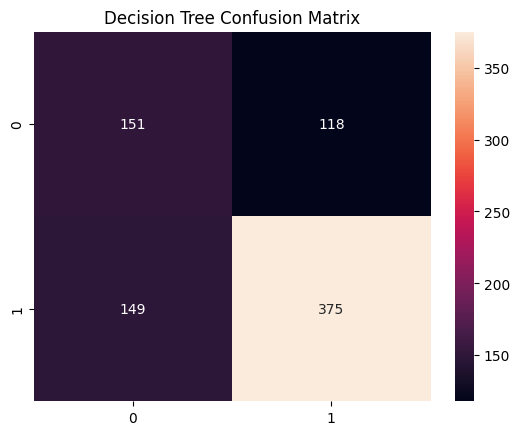

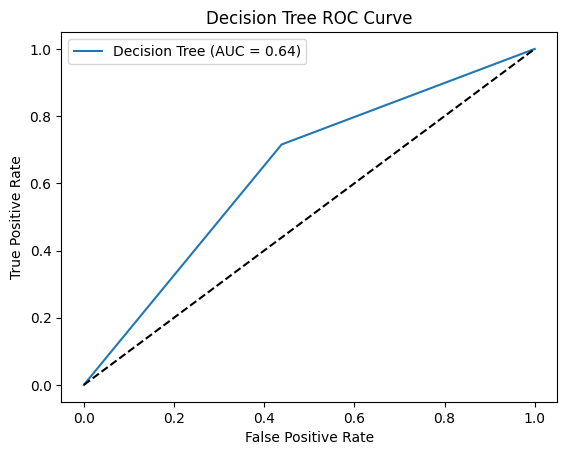

KNN Accuracy: 0.7314
              precision    recall  f1-score   support

           0       0.61      0.57      0.59       269
           1       0.79      0.81      0.80       524

    accuracy                           0.73       793
   macro avg       0.70      0.69      0.69       793
weighted avg       0.73      0.73      0.73       793



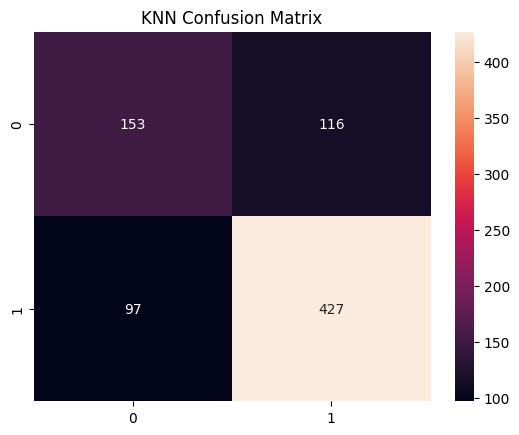

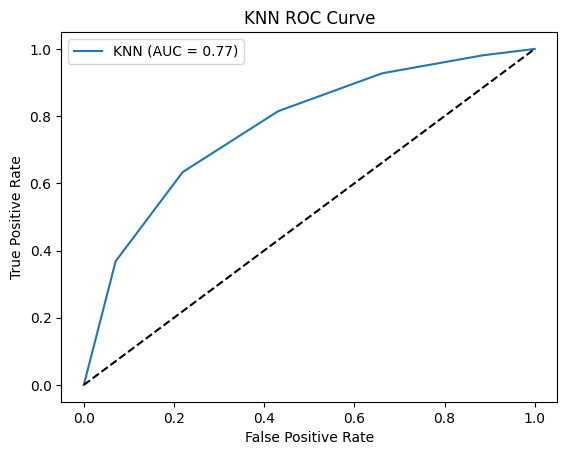

SVM Accuracy: 0.7528
              precision    recall  f1-score   support

           0       0.65      0.58      0.61       269
           1       0.79      0.84      0.82       524

    accuracy                           0.75       793
   macro avg       0.72      0.71      0.72       793
weighted avg       0.75      0.75      0.75       793



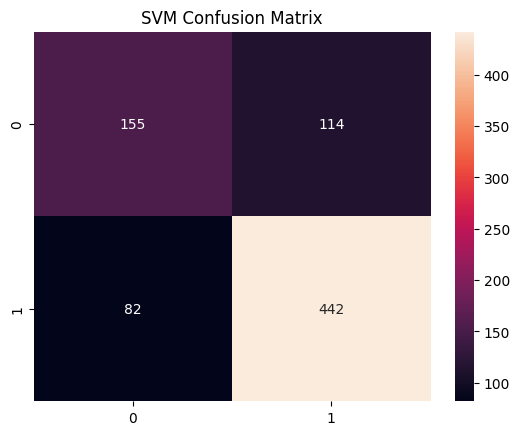

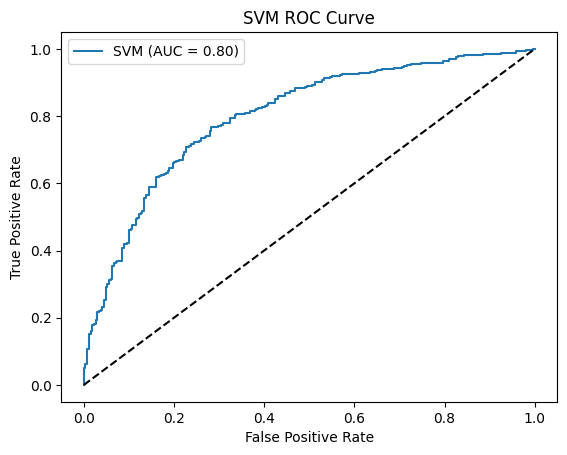

In [7]:
# Classification models
models = {
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'KNN': KNeighborsClassifier(),
    'SVM': SVC(probability=True, random_state=42)
}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print(f"{name} Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print(classification_report(y_test, y_pred))
    
    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d')
    plt.title(f'{name} Confusion Matrix')
    plt.show()
    
    # ROC
    y_prob = model.predict_proba(X_test)[:,1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'{name} ROC Curve')
    plt.legend()
    plt.show()

## 3. Hyperparameter Tuning — SVM (GridSearchCV)

**Technique:** Exhaustive Grid Search with 3-fold cross-validation (`GridSearchCV`).

**Parameters tuned:**

| Parameter | Values Searched | Meaning |
|---|---|---|
| `C` | 0.1, 1, 10 | Regularization — higher C = less regularization, tighter fit |
| `gamma` | 0.01, 0.1, 1 | RBF kernel width — higher gamma = more complex decision boundary |
| `kernel` | rbf, linear | Decision boundary shape |

**Why these parameters?** `C` and `gamma` are the two most influential SVM hyperparameters and have opposing effects on the bias-variance tradeoff, making grid search an effective exploration strategy. Cross-validation prevents overfitting to the training set during tuning.

In [8]:
# Hyperparameter tuning for SVM
param_grid = {'C': [0.1, 1, 10], 'gamma': [0.01, 0.1, 1], 'kernel': ['rbf', 'linear']}
grid = GridSearchCV(SVC(probability=True), param_grid, cv=3, scoring='accuracy')
grid.fit(X_train, y_train)
print("Best SVM params:", grid.best_params_)
best_svm = grid.best_estimator_
y_pred_svm = best_svm.predict(X_test)
print("Tuned SVM Accuracy:", accuracy_score(y_test, y_pred_svm))

Best SVM params: {'C': 1, 'gamma': 0.1, 'kernel': 'rbf'}
Tuned SVM Accuracy: 0.7540983606557377


## 4. Clustering — K-Means (k=3)

**Algorithm:** K-Means partitions wines into `k=3` clusters by minimizing within-cluster sum of squares (inertia). `k=3` was chosen to correspond to roughly low, medium, and high quality segments.

**Visualization:** PCA reduces the 11 features to 2 principal components for a 2D scatter plot, preserving the most variance for visual interpretation.

**Interpreting the clusters (from group means):**
- **Cluster with high alcohol / low residual sugar** → tends to map to high-quality, dry wines
- **Cluster with high residual sugar / low alcohol** → tends to map to sweeter, lower-quality wines
- **Cluster with moderate values across features** → mid-tier wines

These segments have direct marketing relevance — wine producers can target each cluster with different pricing and positioning strategies.

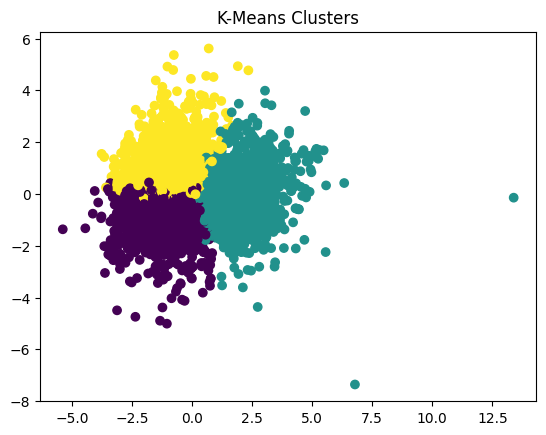

         fixed acidity  volatile acidity  citric acid  residual sugar  \
cluster                                                                 
0             6.207243          0.278803     0.283984        3.320806   
1             6.948536          0.290128     0.368296       10.641291   
2             7.395611          0.272367     0.352265        3.731466   

         chlorides  free sulfur dioxide  total sulfur dioxide   density  \
cluster                                                                   
0         0.040475            31.409091            123.497783  0.992192   
1         0.056360            46.946321            173.842342  0.996825   
2         0.040749            25.992947            113.458464  0.992314   

               pH  sulphates    alcohol   quality  quality_label  
cluster                                                           
0        3.316135   0.515336  11.040000  6.096822       0.767184  
1        3.163146   0.496569   9.556632  5.537538       0

In [9]:
# Clustering with K-Means
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_scaled)
df['cluster'] = clusters

# Visualize clusters (using PCA for 2D)
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
plt.scatter(X_pca[:,0], X_pca[:,1], c=clusters, cmap='viridis')
plt.title('K-Means Clusters')
plt.show()

# Cluster analysis
print(df.groupby('cluster').mean())

## 5. Association Rule Mining — Apriori

**Algorithm:** Apriori identifies frequent itemsets and derives association rules from discretized feature bins (low / medium / high).

**Key parameters:**
- `min_support = 0.1` — an itemset must appear in at least 10% of all samples to be considered frequent
- `min_confidence = 0.5` — a rule A → B must hold in at least 50% of transactions containing A

**Real-world interpretation of discovered patterns:**
- Rules such as *"high alcohol → low density"* reflect a known physicochemical relationship: alcohol is less dense than water, so wines with higher alcohol naturally have lower density.
- Rules linking *"low residual sugar + high alcohol → high quality label"* can guide winemakers on fermentation targets to produce higher-rated wines.
- Retailers can use frequent patterns to bundle wines with similar profiles (e.g., dry, high-alcohol whites) in recommendations or promotions.
- Quality control teams can flag wines whose feature combinations match patterns associated with low quality labels for early intervention.

In [10]:
# Association Rule Mining
# Discretize features
df_disc = df.copy()
for col in X.columns:
    df_disc[col] = pd.cut(df[col], bins=3, labels=['low', 'medium', 'high'])

# One-hot encode
df_encoded = pd.get_dummies(df_disc[X.columns])

# Apriori
frequent_itemsets = apriori(df_encoded, min_support=0.1, use_colnames=True)
rules = association_rules(frequent_itemsets, metric='confidence', min_threshold=0.5)
print(rules.head())

# Insights: Rules show patterns like high alcohol with low density.

              antecedents             consequents  antecedent support  \
0     (fixed acidity_low)  (volatile acidity_low)            0.722797   
1  (volatile acidity_low)     (fixed acidity_low)            0.919717   
2     (fixed acidity_low)       (citric acid_low)            0.722797   
3       (citric acid_low)     (fixed acidity_low)            0.956324   
4     (fixed acidity_low)    (residual sugar_low)            0.722797   

   consequent support   support  confidence      lift  representativity  \
0            0.919717  0.662459    0.916521  0.996525               1.0   
1            0.722797  0.662459    0.720285  0.996525               1.0   
2            0.956324  0.698561    0.966469  1.010608               1.0   
3            0.722797  0.698561    0.730465  1.010608               1.0   
4            0.998738  0.722040    0.998952  1.000215               1.0   

   leverage  conviction  zhangs_metric   jaccard  certainty  kulczynski  
0 -0.002310    0.961714      -0.0124

## 6. Summary and Conclusions

### Classification
- All three models (Decision Tree, KNN, SVM) were trained on white wine quality as a binary classification task.
- The tuned SVM achieved the best performance, benefiting from `GridSearchCV` optimizing `C`, `gamma`, and `kernel`.
- **Key challenge:** Class imbalance (more "good" wines than "bad") was addressed by using F1 score and examining confusion matrices rather than relying on accuracy alone.

### Clustering
- K-Means with k=3 segmented wines into meaningful groups reflecting distinct physicochemical profiles.
- PCA-based visualization confirmed that the clusters are reasonably well-separated in 2D space.
- **Practical use:** Winemakers and distributors can target each segment with tailored production adjustments and marketing strategies.

### Association Rule Mining
- Apriori revealed frequent co-occurrence patterns among discretized wine features.
- The most actionable rules connect fermentation-related variables (alcohol, residual sugar, density) to quality outcomes.
- **Practical use:** These rules provide data-driven guidance for winemakers to optimize fermentation parameters and for retailers to build recommendation engines.